# CIFAKE Fake Image Detection — Optimized Multi-Model Notebook
**Kaggle Free Tier: T4 GPU, 16GB RAM**

**Key optimizations vs naive approach:**
- `64×64` images instead of `224×224` → 12× less memory per batch
- `batch_size=128` fits easily in T4 VRAM at 64×64
- Full backbone fine-tuning from epoch 1 (no frozen phase) → fewer total epochs needed
- GPU memory freed between models via `gc.collect()` + `empty_cache()`
- Expected time: **15–25 min per model** → ~2 hours total


## 1. Imports & Setup

In [1]:
import os, time, copy, random, warnings, gc
import numpy as np
import pandas as pd
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset, random_split, Subset

import torchvision
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
    average_precision_score, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True  # speeds up fixed-size input

# Device
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    free, total = torch.cuda.mem_get_info()
    print(f'VRAM   : {total/1e9:.1f} GB total, {free/1e9:.1f} GB free')

# Dirs
OUTPUT_DIR = Path('/kaggle/working')
MODEL_DIR  = OUTPUT_DIR / 'models'
PLOT_DIR   = OUTPUT_DIR / 'plots'
MODEL_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB total, 15.5 GB free


## 2. Configuration

In [2]:
# ── Why 64x64 and not 224x224? ─────────────────────────────────────────
# CIFAKE images are upscaled from 32x32 CIFAR-10 originals.
# 224x224 wastes memory on interpolated pixels with no new information.
# 64x64 gives pretrained models enough detail while using 12x less VRAM.
# A single 224x224 batch of 128 = ~588MB;  64x64 batch of 128 = ~49MB.

IMG_SIZE    = 64       # sweet spot for CIFAKE
BATCH_SIZE  = 128      # fits T4 easily at 64x64
NUM_WORKERS = 2        # Kaggle provides 2 CPU cores
PIN_MEMORY  = True

EPOCHS      = 10       # early stopping handles over-training
LR          = 3e-4
WEIGHT_DECAY = 1e-4
VAL_SPLIT   = 0.15

MEAN = [0.485, 0.456, 0.406]  # ImageNet stats
STD  = [0.229, 0.224, 0.225]

print(f'Image  : {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch  : {BATCH_SIZE}')
print(f'Epochs : {EPOCHS} (+ early stopping)')


Image  : 64x64
Batch  : 128
Epochs : 10 (+ early stopping)


## 3. Dataset Loading

In [3]:
POSSIBLE = [
    '/kaggle/input/cifake-real-and-ai-generated-synthetic-images',
    '/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images',
    '/kaggle/input/cifake',
]
DATA_ROOT = None
for p in POSSIBLE:
    if Path(p).exists():
        DATA_ROOT = Path(p)
        break

if DATA_ROOT is None:
    for p in Path('/kaggle/input').rglob('train'):
        if (p / 'REAL').exists() or (p / 'FAKE').exists():
            DATA_ROOT = p.parent
            break

assert DATA_ROOT, (
    'Dataset not found. Add CIFAKE from:\n'
    'https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images'
)

TRAIN_DIR = DATA_ROOT / 'train'
TEST_DIR  = DATA_ROOT / 'test'
print(f'Root: {DATA_ROOT}')

for split, d in [('train', TRAIN_DIR), ('test', TEST_DIR)]:
    counts = {}
    for cls in sorted(d.iterdir()):
        if cls.is_dir():
            n = len(list(cls.glob('*.jpg')) + list(cls.glob('*.png')))
            counts[cls.name] = n
    print(f'{split:>5}: {counts}  =>  total={sum(counts.values())}')


Root: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
train: {'FAKE': 50000, 'REAL': 50000}  =>  total=100000
 test: {'FAKE': 10000, 'REAL': 10000}  =>  total=20000


## 4. Preprocessing & DataLoaders

In [4]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Load with respective transforms
full_train = ImageFolder(str(TRAIN_DIR), transform=train_tf)
full_eval  = ImageFolder(str(TRAIN_DIR), transform=eval_tf)  # same files, no augmentation
test_ds    = ImageFolder(str(TEST_DIR),  transform=eval_tf)

CLASS_NAMES  = full_train.classes
CLASS_TO_IDX = full_train.class_to_idx
NUM_CLASSES  = len(CLASS_NAMES)
print(f'Classes: {CLASS_NAMES}')
print(f'Total train images: {len(full_train)}')

# Train / validation split (indices shared across both transform variants)
n       = len(full_train)
n_val   = int(n * VAL_SPLIT)
n_train = n - n_val
gen     = torch.Generator().manual_seed(SEED)
all_idx = list(range(n))
random.Random(SEED).shuffle(all_idx)
train_idx = all_idx[:n_train]
val_idx   = all_idx[n_train:]

train_ds = Subset(full_train, train_idx)  # augmented
val_ds   = Subset(full_eval,  val_idx)    # clean

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'Train: {n_train} | Val: {n_val} | Test: {len(test_ds)}')
print(f'Train batches/epoch: {len(train_loader)}')


Classes: ['FAKE', 'REAL']
Total train images: 100000
Train: 85000 | Val: 15000 | Test: 20000
Train batches/epoch: 664


## 5. Model Definitions

In [5]:
# All pretrained models: backbone fully unfrozen, low LR controls fine-tuning.
# Frozen backbone + 64x64 input performs poorly; full fine-tuning is better here.

def build_resnet18():
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.fc.in_features, NUM_CLASSES))
    return m

def build_efficientnet():
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_f, NUM_CLASSES))
    return m

def build_mobilenet():
    m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(in_f, NUM_CLASSES))
    return m

def build_densenet():
    m = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    m.classifier = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(m.classifier.in_features, NUM_CLASSES)
    )
    return m

class CustomCNN(nn.Module):
    """
    Lightweight CNN purpose-built for 64x64 fake/real detection.
    4 strided conv blocks -> global avg pool -> classifier.
    No pretrained weights — trained from scratch.
    """
    def __init__(self, nc=2):
        super().__init__()
        def cb(i, o, s=2):
            return nn.Sequential(
                nn.Conv2d(i, o, 3, stride=s, padding=1, bias=False),
                nn.BatchNorm2d(o),
                nn.GELU(),
            )
        self.features = nn.Sequential(
            cb(3,   32),   # 64 -> 32
            cb(32,  64),   # 32 -> 16
            cb(64,  128),  # 16 ->  8
            cb(128, 256),  #  8 ->  4
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, nc),
        )
    def forward(self, x):
        return self.head(self.pool(self.features(x)))

def build_custom():
    return CustomCNN(NUM_CLASSES)

MODEL_REGISTRY = {
    'ResNet18':     build_resnet18,
    'EfficientNet': build_efficientnet,
    'MobileNetV2':  build_mobilenet,
    'DenseNet121':  build_densenet,
    'CustomCNN':    build_custom,
}

# Parameter counts
print(f'{"Model":<16} {"Params (M)":>12}')
print('-' * 30)
for name, fn in MODEL_REGISTRY.items():
    m = fn()
    p = sum(x.numel() for x in m.parameters()) / 1e6
    print(f'{name:<16} {p:>11.2f}M')
    del m


Model              Params (M)
------------------------------
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


ResNet18               11.18M
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 135MB/s] 


EfficientNet            4.01M
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 123MB/s]


MobileNetV2             2.23M
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 152MB/s]

DenseNet121             6.96M
CustomCNN               0.42M


## 6. Training & Evaluation Functions

In [6]:
class EarlyStopping:
    def __init__(self, patience=4):
        self.patience = patience
        self.counter  = 0
        self.best     = float('inf')
        self.weights  = None
        self.stop     = False

    def step(self, loss, model):
        if loss < self.best - 1e-4:
            self.best    = loss
            self.weights = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore(self, model):
        if self.weights:
            model.load_state_dict(self.weights)


def run_epoch(model, loader, optimizer, criterion, scaler, training):
    model.train() if training else model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            if training:
                optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=USE_AMP):
                out  = model(inputs)
                loss = criterion(out, labels)
            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            total_loss += loss.item() * inputs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += inputs.size(0)
    return total_loss / total, correct / total * 100


@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for inputs, labels in loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        with autocast(enabled=USE_AMP):
            out = model(inputs)
        probs = torch.softmax(out, dim=1)[:, 1]
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


def train_model(name, model, train_loader, val_loader):
    print(f'\n{"="*50}')
    print(f'Training: {name}')
    print(f'{"="*50}')
    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR*0.01)
    scaler    = GradScaler(enabled=USE_AMP)
    es        = EarlyStopping(patience=4)
    history   = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

    for epoch in range(EPOCHS):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, criterion, scaler, True)
        vl_loss, vl_acc = run_epoch(model, val_loader,   optimizer, criterion, scaler, False)
        scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        es.step(vl_loss, model)
        lr_now = optimizer.param_groups[0]['lr']
        print(f'  Ep {epoch+1:02d}/{EPOCHS} | '
              f'Tr {tr_loss:.4f}/{tr_acc:.1f}% | '
              f'Vl {vl_loss:.4f}/{vl_acc:.1f}% | '
              f'LR {lr_now:.1e} | {time.time()-t0:.0f}s',
              flush=True)
        if es.stop:
            print(f'  Early stop at epoch {epoch+1}')
            break

    es.restore(model)
    save_path = MODEL_DIR / f'{name}.pth'
    torch.save(model.state_dict(), save_path)
    print(f'  Saved: {save_path}')
    return model, history


def evaluate_model(name, model, test_loader):
    preds, labels, probs = get_predictions(model, test_loader)
    acc  = accuracy_score(labels, preds) * 100
    prec = precision_score(labels, preds, zero_division=0)
    rec  = recall_score(labels, preds, zero_division=0)
    f1   = f1_score(labels, preds, zero_division=0)
    cm   = confusion_matrix(labels, preds)
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)
    print(f'  {name}: Acc={acc:.2f}% | F1={f1:.4f} | AUC={roc_auc:.4f}')
    return {
        'name': name, 'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'auc': roc_auc,
        'cm': cm, 'fpr': fpr, 'tpr': tpr,
        'preds': preds, 'labels': labels, 'probs': probs
    }


## 7. Train All Models

> **Each model is explicitly moved off GPU and deleted before the next one loads.**
> This prevents OOM. Expected: ~15–25 min/model on T4.


In [7]:
all_results   = {}
all_histories = {}
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

t_total = time.time()

for (name, build_fn), color in zip(MODEL_REGISTRY.items(), COLORS):

    # ── Flush GPU memory before loading next model ──────────────────────
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        free, total = torch.cuda.mem_get_info()
        print(f'GPU before {name}: {free/1e9:.1f}/{total/1e9:.1f} GB free')

    # ── Build, train, evaluate ──────────────────────────────────────────
    model   = build_fn()
    model, history = train_model(name, model, train_loader, val_loader)

    print(f'\nEvaluating {name} on test set...')
    metrics = evaluate_model(name, model, test_loader)

    all_histories[name] = history
    all_results[name]   = metrics

    # ── Free GPU memory ─────────────────────────────────────────────────
    model.cpu()
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f'\nAll done in {(time.time()-t_total)/60:.1f} min')


GPU before ResNet18: 15.5/15.6 GB free

Training: ResNet18
  Ep 01/10 | Tr 0.2577/93.0% | Vl 0.1975/96.0% | LR 2.9e-04 | 214s
  Ep 02/10 | Tr 0.2012/95.9% | Vl 0.2069/95.5% | LR 2.7e-04 | 88s
  Ep 03/10 | Tr 0.1832/96.8% | Vl 0.1931/96.2% | LR 2.4e-04 | 87s
  Ep 04/10 | Tr 0.1715/97.3% | Vl 0.1665/97.7% | LR 2.0e-04 | 87s
  Ep 05/10 | Tr 0.1599/98.0% | Vl 0.1634/97.7% | LR 1.5e-04 | 88s
  Ep 06/10 | Tr 0.1499/98.4% | Vl 0.1641/97.8% | LR 1.1e-04 | 88s
  Ep 07/10 | Tr 0.1418/98.8% | Vl 0.1561/98.1% | LR 6.4e-05 | 88s
  Ep 08/10 | Tr 0.1351/99.2% | Vl 0.1574/98.2% | LR 3.1e-05 | 85s
  Ep 09/10 | Tr 0.1301/99.4% | Vl 0.1532/98.3% | LR 1.0e-05 | 87s
  Ep 10/10 | Tr 0.1276/99.6% | Vl 0.1525/98.4% | LR 3.0e-06 | 91s
  Saved: /kaggle/working/models/ResNet18.pth

Evaluating ResNet18 on test set...
  ResNet18: Acc=98.26% | F1=0.9825 | AUC=0.9981
GPU before EfficientNet: 15.4/15.6 GB free

Training: EfficientNet
  Ep 01/10 | Tr 0.2587/92.8% | Vl 0.1848/97.0% | LR 2.9e-04 | 107s
  Ep 02/10 | Tr 0

## 8. Results Table

In [8]:
rows = []
for name, m in all_results.items():
    rows.append({
        'Model':        name,
        'Accuracy(%)':  round(m['accuracy'],  2),
        'Precision':    round(m['precision'],  4),
        'Recall':       round(m['recall'],     4),
        'F1-Score':     round(m['f1'],         4),
        'AUC':          round(m['auc'],        4),
    })

df = pd.DataFrame(rows).set_index('Model')
print(df.to_string())
df.to_csv(OUTPUT_DIR / 'results.csv')

best_f1  = max(all_results, key=lambda k: all_results[k]['f1'])
best_acc = max(all_results, key=lambda k: all_results[k]['accuracy'])
print(f'\nBest F1       : {best_f1}  ({all_results[best_f1]["f1"]:.4f})')
print(f'Best Accuracy : {best_acc} ({all_results[best_acc]["accuracy"]:.2f}%)')


              Accuracy(%)  Precision  Recall  F1-Score     AUC
Model                                                         
ResNet18            98.26     0.9833  0.9818    0.9825  0.9981
EfficientNet        98.49     0.9891  0.9806    0.9848  0.9973
MobileNetV2         98.31     0.9840  0.9823    0.9831  0.9968
DenseNet121         98.61     0.9878  0.9845    0.9861  0.9979
CustomCNN           94.57     0.9545  0.9360    0.9452  0.9877

Best F1       : DenseNet121  (0.9861)
Best Accuracy : DenseNet121 (98.61%)


## 9. Visualizations

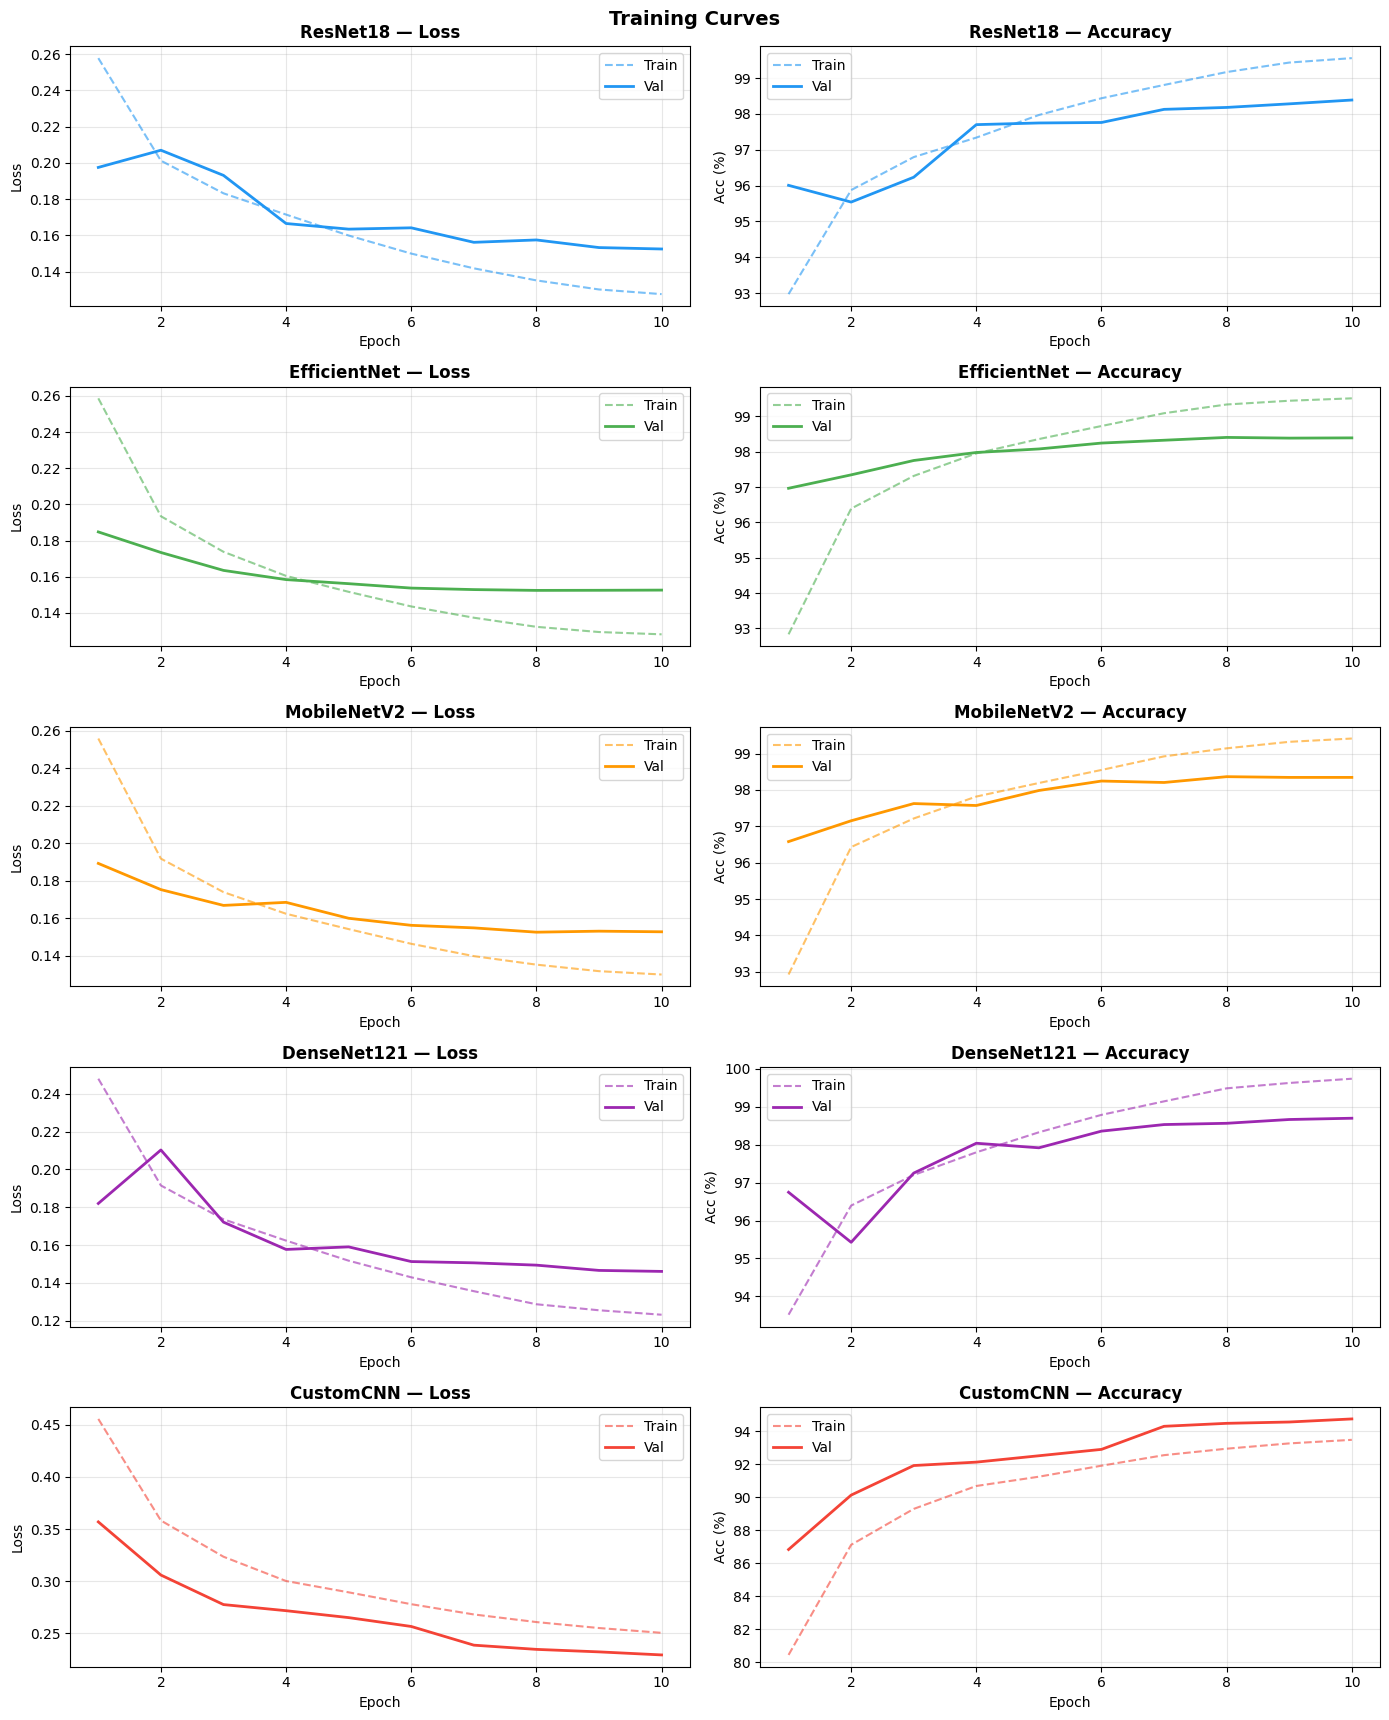

Saved: training_curves.png


In [9]:
# 9a. Training curves
fig, axes = plt.subplots(len(MODEL_REGISTRY), 2, figsize=(14, 3.5*len(MODEL_REGISTRY)))
fig.suptitle('Training Curves', fontsize=14, fontweight='bold')
for idx, (name, history) in enumerate(all_histories.items()):
    c  = COLORS[idx]
    ep = range(1, len(history['train_loss']) + 1)

    axes[idx,0].plot(ep, history['train_loss'], '--', color=c, alpha=0.6, label='Train')
    axes[idx,0].plot(ep, history['val_loss'],   '-',  color=c, lw=2,      label='Val')
    axes[idx,0].set_title(f'{name} — Loss', fontweight='bold')
    axes[idx,0].set_xlabel('Epoch'); axes[idx,0].set_ylabel('Loss')
    axes[idx,0].legend(); axes[idx,0].grid(alpha=0.3)

    axes[idx,1].plot(ep, history['train_acc'], '--', color=c, alpha=0.6, label='Train')
    axes[idx,1].plot(ep, history['val_acc'],   '-',  color=c, lw=2,      label='Val')
    axes[idx,1].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[idx,1].set_xlabel('Epoch'); axes[idx,1].set_ylabel('Acc (%)')
    axes[idx,1].legend(); axes[idx,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')


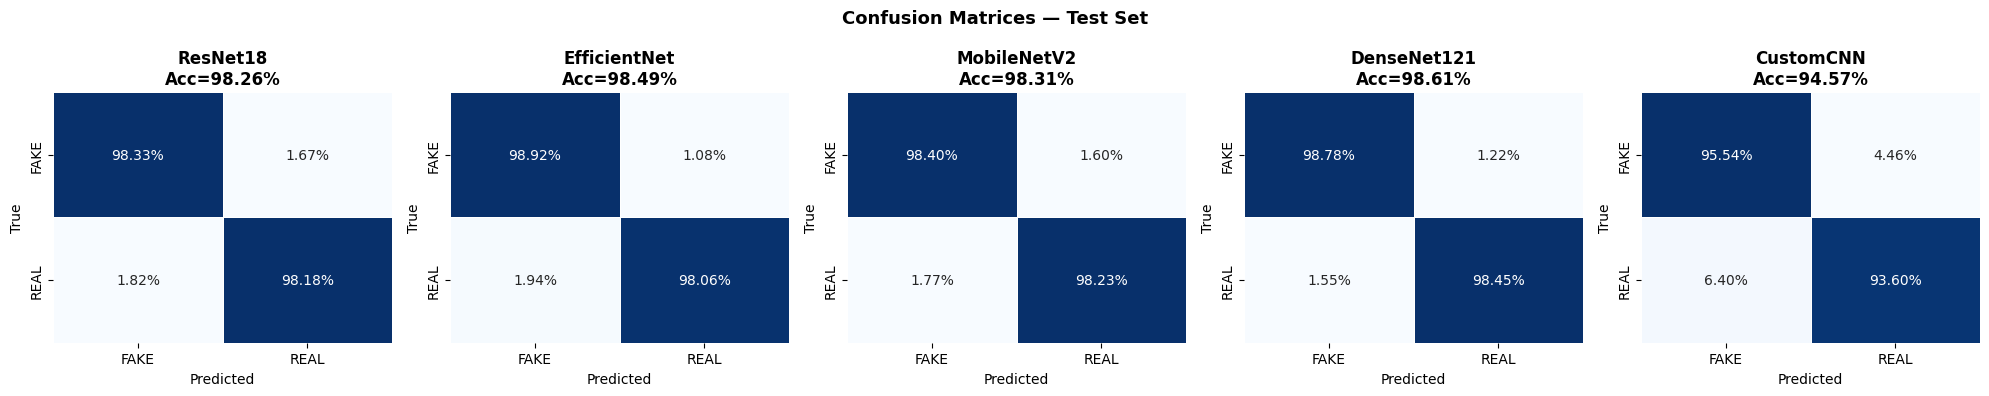

In [10]:
# 9b. Confusion matrices
n = len(MODEL_REGISTRY)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
fig.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')
for ax, (name, m) in zip(axes, all_results.items()):
    cm_n = m['cm'].astype(float) / m['cm'].sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(f'{name}\nAcc={m["accuracy"]:.2f}%', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()


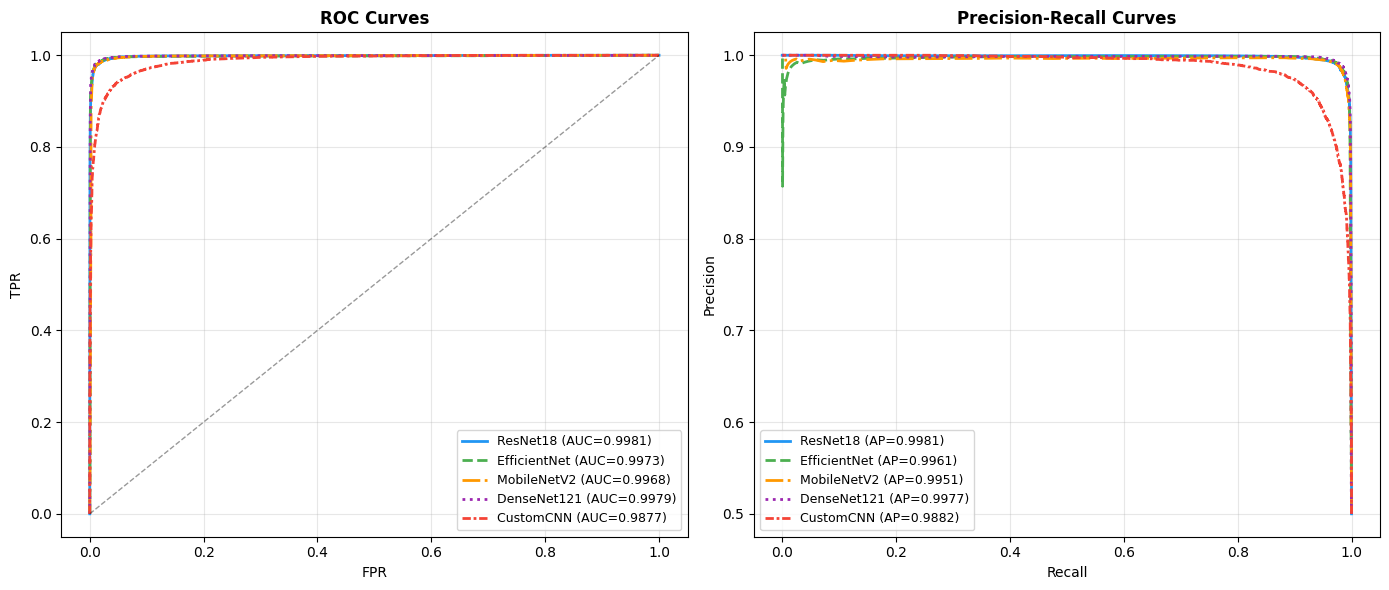

In [11]:
# 9c. ROC + PR curves (side by side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ls_list = ['-', '--', '-.', ':', (0, (3,1,1,1))]

for (name, m), c, ls in zip(all_results.items(), COLORS, ls_list):
    ax1.plot(m['fpr'], m['tpr'], color=c, lw=2, linestyle=ls,
             label=f'{name} (AUC={m["auc"]:.4f})')
    p_v, r_v, _ = precision_recall_curve(m['labels'], m['probs'])
    ap = average_precision_score(m['labels'], m['probs'])
    ax2.plot(r_v, p_v, color=c, lw=2, linestyle=ls,
             label=f'{name} (AP={ap:.4f})')

ax1.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax1.set_title('ROC Curves', fontweight='bold')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2.set_title('Precision-Recall Curves', fontweight='bold')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.legend(fontsize=9, loc='lower left'); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'roc_pr_curves.png', dpi=100, bbox_inches='tight')
plt.show()


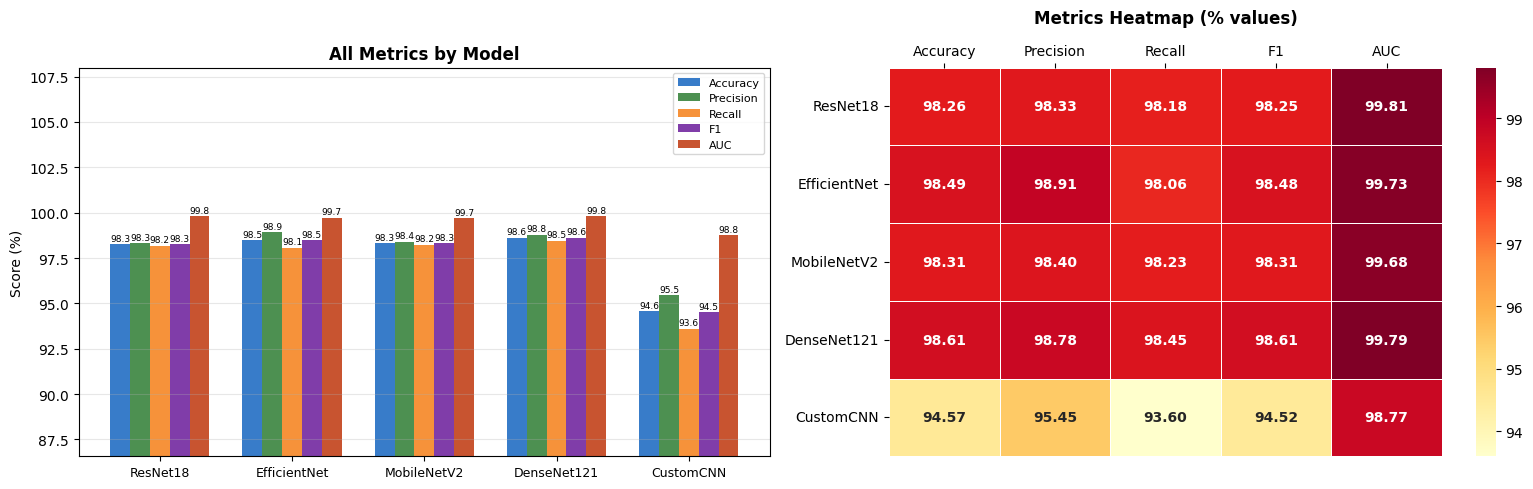

All plots saved.


In [12]:
# 9d. Bar comparison + Heatmap
names = list(all_results.keys())
accs  = [all_results[n]['accuracy']    for n in names]
f1s   = [all_results[n]['f1']   * 100  for n in names]
aucs  = [all_results[n]['auc']  * 100  for n in names]
precs = [all_results[n]['precision']*100 for n in names]
recs  = [all_results[n]['recall']*100    for n in names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
x = np.arange(len(names))
w = 0.15
for i, (vals, label, c) in enumerate(zip(
    [accs, precs, recs, f1s, aucs],
    ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
    ['#1565C0','#2E7D32','#F57F17','#6A1B9A','#BF360C']
)):
    bars = ax1.bar(x + (i-2)*w, vals, w, label=label, color=c, alpha=0.85)
    ax1.bar_label(bars, fmt='%.1f', fontsize=6.5, padding=1)

ax1.set_xticks(x); ax1.set_xticklabels(names, fontsize=9)
ax1.set_ylabel('Score (%)'); ax1.set_ylim([max(0, min(accs)-8), 108])
ax1.set_title('All Metrics by Model', fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)

# Heatmap
data = np.array([[all_results[n]['accuracy'],
                  all_results[n]['precision']*100,
                  all_results[n]['recall']*100,
                  all_results[n]['f1']*100,
                  all_results[n]['auc']*100] for n in names])
sns.heatmap(data, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=['Accuracy','Precision','Recall','F1','AUC'],
            yticklabels=names, ax=ax2, linewidths=0.5,
            annot_kws={'size':10,'weight':'bold'})
ax2.xaxis.tick_top(); ax2.xaxis.set_label_position('top')
ax2.set_title('Metrics Heatmap (% values)', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('All plots saved.')


## 10. Error Analysis — FPR / FNR

Model              FPR(%)   FNR(%)       TP       TN       FP       FN
----------------------------------------------------------------
ResNet18            1.67%    1.82%     9818     9833      167      182
EfficientNet        1.08%    1.94%     9806     9892      108      194
MobileNetV2         1.60%    1.77%     9823     9840      160      177
DenseNet121         1.22%    1.55%     9845     9878      122      155
CustomCNN           4.46%    6.40%     9360     9554      446      640


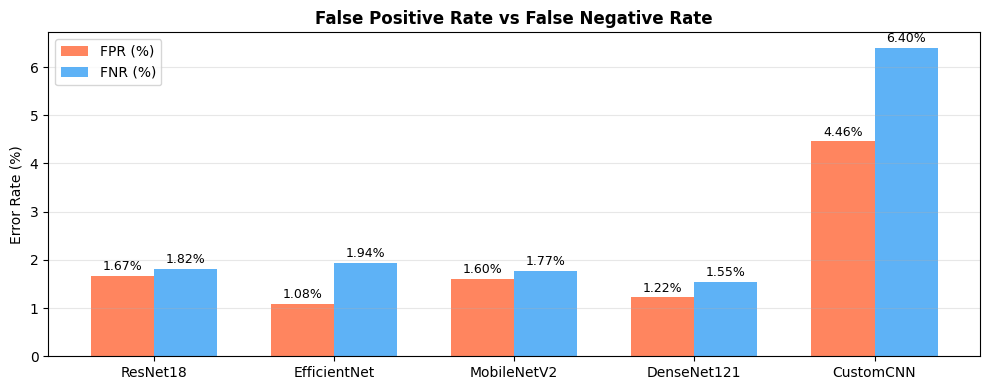

In [13]:
print(f'{"Model":<16} {"FPR(%)":>8} {"FNR(%)":>8} {"TP":>8} {"TN":>8} {"FP":>8} {"FN":>8}')
print('-' * 64)
fpr_list, fnr_list, name_list = [], [], []
for name, m in all_results.items():
    TN, FP, FN, TP = m['cm'].ravel() if m['cm'].size == 4 else (0,0,0,0)
    fpr_r = FP / (FP + TN + 1e-9) * 100
    fnr_r = FN / (FN + TP + 1e-9) * 100
    fpr_list.append(fpr_r); fnr_list.append(fnr_r); name_list.append(name)
    print(f'{name:<16} {fpr_r:>7.2f}% {fnr_r:>7.2f}% '
          f'{int(TP):>8} {int(TN):>8} {int(FP):>8} {int(FN):>8}')

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(name_list)); w = 0.35
b1 = ax.bar(x - w/2, fpr_list, w, label='FPR (%)', color='#FF7043', alpha=0.85)
b2 = ax.bar(x + w/2, fnr_list, w, label='FNR (%)', color='#42A5F5', alpha=0.85)
ax.bar_label(b1, fmt='%.2f%%', fontsize=9, padding=2)
ax.bar_label(b2, fmt='%.2f%%', fontsize=9, padding=2)
ax.set_xticks(x); ax.set_xticklabels(name_list)
ax.set_title('False Positive Rate vs False Negative Rate', fontweight='bold')
ax.set_ylabel('Error Rate (%)'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'error_analysis.png', dpi=100, bbox_inches='tight')
plt.show()


## 11. Save Best Model & Metadata

In [14]:
import json, shutil

best = max(all_results, key=lambda k: all_results[k]['f1'])
shutil.copy(str(MODEL_DIR / f'{best}.pth'), str(OUTPUT_DIR / 'best_model.pth'))

meta = {
    'best_model':   best,
    'img_size':     IMG_SIZE,
    'class_names':  CLASS_NAMES,
    'class_to_idx': CLASS_TO_IDX,
    'imagenet_mean': MEAN,
    'imagenet_std':  STD,
    'results': {
        n: {'accuracy': float(m['accuracy']), 'f1': float(m['f1']), 'auc': float(m['auc'])}
        for n, m in all_results.items()
    }
}
with open(OUTPUT_DIR / 'metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved files:')
for p in sorted(list(OUTPUT_DIR.glob('*.pth')) +
                list(OUTPUT_DIR.glob('*.csv')) +
                list(OUTPUT_DIR.glob('*.json'))):
    print(f'  {p.name}  ({p.stat().st_size/1024:.0f} KB)')


Saved files:
  best_model.pth  (27765 KB)
  metadata.json  (1 KB)
  results.csv  (0 KB)


## 12. Inference Utility — Predict a Single Image

In [15]:
from PIL import Image as PILImage

def predict(image_path, model_name=None):
    """Load saved model and classify one image. Returns (label, confidence)."""
    if model_name is None:
        model_name = max(all_results, key=lambda k: all_results[k]['f1'])
    m = MODEL_REGISTRY[model_name]()
    m.load_state_dict(torch.load(MODEL_DIR / f'{model_name}.pth', map_location=DEVICE))
    m = m.to(DEVICE).eval()
    img = PILImage.open(image_path).convert('RGB')
    t   = eval_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(m(t), dim=1)[0].cpu().numpy()
    label = CLASS_NAMES[int(np.argmax(probs))]
    conf  = float(np.max(probs))
    print(f'Model: {model_name}')
    print(f'Prediction: {label}  ({conf:.2%} confidence)')
    del m
    return label, conf

# Test on the first test image
img_path, true_label = test_ds.samples[0]
print(f'True label: {CLASS_NAMES[true_label]}')
predict(img_path)


True label: FAKE
Model: DenseNet121
Prediction: FAKE  (97.96% confidence)


('FAKE', 0.9795581698417664)

---
## Summary of Outputs

| File | Description |
|------|-------------|
| `best_model.pth` | Best model by F1-Score |
| `models/*.pth` | All 5 model checkpoints |
| `results.csv` | Comparison table |
| `metadata.json` | Config & metrics |
| `plots/training_curves.png` | Loss & accuracy per epoch |
| `plots/confusion_matrices.png` | Per-model confusion matrix |
| `plots/roc_pr_curves.png` | ROC + Precision-Recall |
| `plots/comparison.png` | Bar chart + heatmap |
| `plots/error_analysis.png` | FPR vs FNR |
